<a href="https://colab.research.google.com/github/Parv-01/Kshitij_Sir_Repo_Check_IITP/blob/main/PAL_executability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PAL: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/PAL](https://github.com/Mishrakshitij/PAL)  
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'PAL'
COMMIT = '6cceddce347c8066312db4f7d9a330302f9b8c3e'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: 6cceddce347c8066312db4f7d9a330302f9b8c3e
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


# PAL: bounded executability study
This notebook checks PAL's native supervised counselor policy on a small EPE-HLCC subset. A tiny Hugging Face GPT-2 model is loaded, trained for five optimizer updates, saved, reloaded, and evaluated on four held-out counselor responses. Preference models, emotion classification, and PPO remain outside this bounded run.

This notebook evaluates execution of the released implementation; it does not reproduce paper-level dialogue quality.

In [ ]:
import gc
import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

sys.path.insert(0, str(REPO_ROOT / "src"))
from pal.data import verify_data_repository, load_split_rows, build_examples
from pal.config import TrainConfig
from pal.models import CausalPolicy
from pal.training import train_supervised, evaluate_policy, examples_for

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(2)
torch.manual_seed(10)
COMMIT = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()
print("Repository: https://github.com/Mishrakshitij/PAL")
print("Commit:", COMMIT)
print("Runtime:", DEVICE, "| PyTorch:", torch.__version__)

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: https://github.com/Mishrakshitij/PAL
Commit: 6cceddce347c8066312db4f7d9a330302f9b8c3e
Runtime: cuda | PyTorch: 2.13.0+cu129


## Dataset integrity and exploratory analysis
The native verifier checks utterance schemas, hashes, role-specific labels, and partition isolation.

,dataset,dialogues,utterances,response_examples,unique_transcripts
0,EPE-enEIH,1814,44247,21223,1812
1,EPE-HLCC,258,10959,5313,253


,dialogue_id,turn_id,speaker,text,emotion,empathy,politeness,conversation_type
0,0,0,counselor,hey Monica how are you doing today,,0,1,high_001
1,0,1,client,I'm okay right now but I'm a little anxious be...,afraid,,,high_001
2,0,2,counselor,so it sounds like you really want to go to Bla...,,2,2,high_001
3,0,3,client,yeah Monaco but interesting but I was thinking...,hopeful,,,high_001


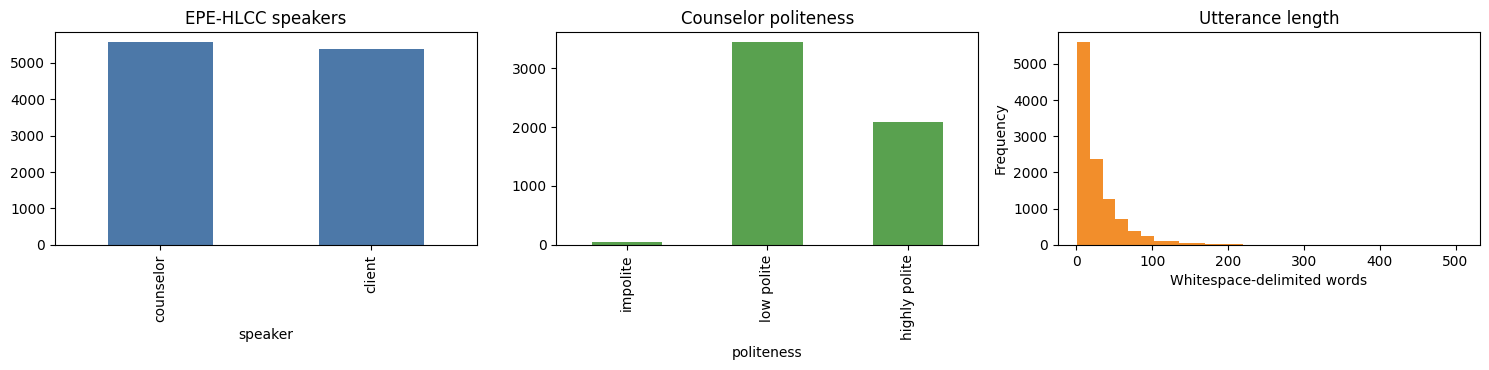

In [ ]:
verification = verify_data_repository(REPO_ROOT / "data")
overview = pd.DataFrame([{"dataset": name, "dialogues": result["dialogues"], "utterances": result["utterances"],
                          "response_examples": result["response_examples"], "unique_transcripts": result["unique_dialogue_transcripts"]}
                         for name, result in verification.items()])
display(overview)
data = pd.read_csv(REPO_ROOT / "data/EPE-HLCC/utterances.csv", keep_default_na=False)
display(data.head(4))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
data["speaker"].value_counts().plot.bar(ax=axes[0], color="#4C78A8", title="EPE-HLCC speakers")
data.loc[data["speaker"].eq("counselor"), "politeness"].astype(str).value_counts().sort_index().rename(index={"0": "impolite", "1": "low polite", "2": "highly polite"}).plot.bar(ax=axes[1], color="#59A14F", title="Counselor politeness")
data["text"].str.split().str.len().plot.hist(ax=axes[2], bins=30, color="#F28E2B", title="Utterance length")
axes[2].set_xlabel("Whitespace-delimited words")
plt.tight_layout()
plt.show()

## Native subset construction
The trainer's limit selects eight examples from each of its training and validation partitions. Five total updates use batch size two across at most two epochs. Four examples from the separate test partition are reserved for inference and evaluation; complete dialogue membership remains isolated.

In [ ]:
dataset = REPO_ROOT / "data/EPE-HLCC"
configuration = TrainConfig(policy_model=CAUSAL_MODEL, epochs=2, batch_size=2,
                            max_source_length=48, max_target_length=12,
                            learning_rate=5e-4, device=DEVICE, seed=10)
selected = {split: examples_for(dataset, split, configuration, limit=4 if split == "test" else 8)
            for split in ("train", "validation", "test")}
assert [len(selected[key]) for key in ("train", "validation", "test")] == [8, 8, 4]
members = {split: {example.dialogue_id for example in examples} for split, examples in selected.items()}
assert not (members["train"] & members["validation"] or members["train"] & members["test"] or members["validation"] & members["test"])
display(pd.DataFrame([{"split": split, "selected_examples": len(rows), "selected_dialogues": len(members[split])}
                      for split, rows in selected.items()]))
display(pd.DataFrame([{"dialogue_id": e.dialogue_id, "turn_id": e.turn_id, "client": e.client_utterance,
                       "emotion": e.emotion, "response": e.response} for e in selected["train"][:4]]))
(OUTPUT_DIR / "subset_ids.json").write_text(json.dumps({split: [{"dialogue_id": e.dialogue_id, "turn_id": e.turn_id} for e in rows] for split, rows in selected.items()}, indent=2))

,split,selected_examples,selected_dialogues
0,train,8,1
1,validation,8,1
2,test,4,1


,dialogue_id,turn_id,client,emotion,response
0,1,1,hi there I'm just here to get a refill on my i...,content,hi my name is Laura I'm the pharmacist let me ...
1,1,3,sure,content,your person laughing
2,1,5,reset feels,content,and your date of birth
3,1,7,April 28 1962,content,okay I see that you've filled it here before


1232

## Native model loading, training, and checkpoint selection
PAL's CausalPolicy adapter constructs the emotion-conditioned counselor prompt and masks source tokens from the response loss. The native training loop performs five optimizer updates and retains the checkpoint with the lowest validation loss. Parameter change is measured against the downloaded starting weights.

Hugging Face model: sshleifer/tiny-gpt2 | Parameters: 102,714


{"task": "policy", "epoch": 1, "steps": 4, "train_loss": 10.823254094404334, "validation_loss": 10.830960309958156}


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


{"task": "policy", "epoch": 2, "steps": 5, "train_loss": 10.819272994995117, "validation_loss": 10.830880780763264}


,epoch,steps,train_loss,validation_loss
0,1,4,10.823254,10.830960
1,2,5,10.819273,10.830881


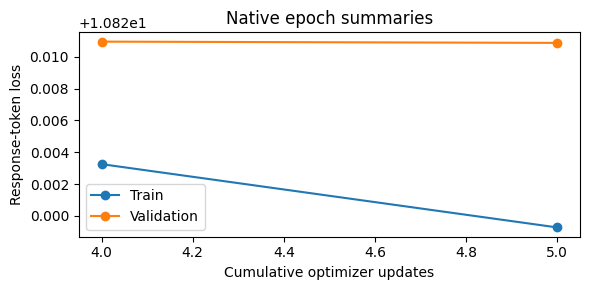

In [ ]:
baseline = CausalPolicy(CAUSAL_MODEL, configuration)
parameter_count = sum(parameter.numel() for parameter in baseline.model.parameters())
initial = {name: value.detach().cpu().clone() for name, value in baseline.model.named_parameters()}
del baseline
gc.collect()
print("Hugging Face model:", CAUSAL_MODEL, "| Parameters:", f"{parameter_count:,}")
checkpoint = OUTPUT_DIR / "checkpoint"
history = train_supervised(dataset, checkpoint, configuration, task="policy", limit=8, max_steps=5)
updates = history[-1]["steps"]
assert updates == 5 and all(math.isfinite(row["train_loss"]) and math.isfinite(row["validation_loss"]) for row in history)
assert (checkpoint / "config.json").is_file() and (checkpoint / "pal_task.json").is_file()
assert any(checkpoint.glob("*.safetensors"))
display(pd.DataFrame(history))
fig, axis = plt.subplots(figsize=(6, 3))
axis.plot([row["steps"] for row in history], [row["train_loss"] for row in history], marker="o", label="Train")
axis.plot([row["steps"] for row in history], [row["validation_loss"] for row in history], marker="o", label="Validation")
axis.set(xlabel="Cumulative optimizer updates", ylabel="Response-token loss", title="Native epoch summaries")
axis.legend()
plt.tight_layout()
plt.show()

## Checkpoint reload and four-example evaluation

The selected policy is reloaded and its changed parameters checked. Native text metrics, including METEOR with WordNet, use the same four held-out counselor responses. Existing saved predictions and likelihood metrics are reused when available; on a fresh notebook run the native evaluator generates those four responses first. This cell performs no optimizer updates.

In [ ]:
# Reuse saved predictions for optional text metrics; no optimizer updates.
import gc, json, math, os, subprocess, sys
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import nltk
import pandas as pd
import torch
from IPython.display import display
sys.path.insert(0, str(REPO_ROOT / "src"))
from pal.config import TrainConfig
from pal.models import CausalPolicy
from pal.training import evaluate_policy, examples_for
from pal.evaluation import evaluate_texts

# Use the configured corpus directory, or install WordNet locally when repeating the notebook.
if os.environ.get("NLTK_DATA"):
    nltk.data.path.insert(0, os.environ["NLTK_DATA"])
try:
    nltk.corpus.wordnet.ensure_loaded()
except LookupError:
    corpus_directory = OUTPUT_DIR / "nltk_data"
    corpus_directory.mkdir(parents=True, exist_ok=True)
    nltk.download("wordnet", download_dir=str(corpus_directory), quiet=True, raise_on_error=True)
    nltk.data.path.insert(0, str(corpus_directory))
    nltk.corpus.wordnet.ensure_loaded()
print("NLTK WordNet: available")

checkpoint = OUTPUT_DIR / "checkpoint"
configuration = replace(TrainConfig.load(checkpoint / "training_config.json"), device=DEVICE)
history = json.loads((checkpoint / "training_metrics.json").read_text())
assert history[-1]["steps"] == 5
previous_result = json.loads((OUTPUT_DIR / "result.json").read_text()) if (OUTPUT_DIR / "result.json").exists() else {}
baseline = CausalPolicy(CAUSAL_MODEL, configuration)
initial_parameters = {name: value.detach().cpu().clone() for name, value in baseline.model.named_parameters()}
parameter_count = sum(value.numel() for value in baseline.model.parameters())
del baseline
reloaded = CausalPolicy(checkpoint, configuration)
parameter_delta = sum(float((value.detach().cpu() - initial_parameters[name]).abs().sum()) for name, value in reloaded.model.named_parameters())
assert math.isfinite(parameter_delta) and parameter_delta > 0
recheck = CausalPolicy(checkpoint, configuration)
max_reload_difference = max(float((value.detach().cpu() - recheck.model.state_dict()[name].detach().cpu()).abs().max()) for name, value in reloaded.model.state_dict().items())
assert max_reload_difference == 0
del reloaded, recheck, initial_parameters
gc.collect()

dataset = REPO_ROOT / "data/EPE-HLCC"
evaluation_dir = OUTPUT_DIR / "evaluation"
prediction_path = evaluation_dir / "predictions.jsonl"
reuse_predictions = prediction_path.exists()
if not reuse_predictions:
    evaluate_policy(dataset, checkpoint, evaluation_dir, configuration, split="test", limit=4)
predictions = [json.loads(line) for line in prediction_path.read_text().splitlines()]
expected_examples = examples_for(dataset, "test", configuration, limit=4)
assert len(predictions) == 4
assert [(row["dialogue_id"], row["turn_id"]) for row in predictions] == [(example.dialogue_id, example.turn_id) for example in expected_examples]
assert [row["reference"] for row in predictions] == [example.response for example in expected_examples]
metrics = json.loads((evaluation_dir / "metrics.json").read_text())
metrics.update(evaluate_texts([row["prediction"] for row in predictions], [row["reference"] for row in predictions]))
assert metrics["n_examples"] == 4 and math.isfinite(metrics["response_nll"]) and math.isfinite(metrics["perplexity"])
assert metrics["meteor"] is not None and math.isfinite(metrics["meteor"])
assert not metrics["unavailable_metrics"]
(evaluation_dir / "metrics.json").write_text(json.dumps(metrics, indent=2, allow_nan=False))
display(pd.DataFrame([{key: value for key, value in metrics.items() if not isinstance(value, dict)}]))
display(pd.DataFrame(predictions))
dataset_rows = sum(json.loads((REPO_ROOT / "data" / name / "stats.json").read_text())["utterances"] for name in ("EPE-enEIH", "EPE-HLCC"))
result = {**previous_result, "project": "PAL", "status": "PASS", "scope": "native supervised EPE-HLCC counselor policy",
          "model": CAUSAL_MODEL, "commit": subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip(),
          "parameters": parameter_count, "updates": history[-1]["steps"],
          "counts": {"train": 8, "validation": 8, "evaluation": 4},
          "metrics": metrics, "training_history": history,
          "parameter_l1_change": parameter_delta, "reload_max_abs_difference": max_reload_difference,
          "dataset_integrity": "PASS", "dataset_rows": dataset_rows,
          "checkpoints": ["checkpoint"], "predictions": predictions,
          "limitations": ["Preference models, emotion classifier, and PPO are not exercised.",
                          "Five-step tiny-model execution does not establish converged quality or reproduce paper results."],
          "metrics_refreshed_utc": datetime.now(timezone.utc).isoformat(),
          "inference_refresh": {"optimizer_updates": 0, "same_heldout_samples": 4,
                                "reused_predictions": reuse_predictions, "newly_generated_responses": 0 if reuse_predictions else 4}}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False))
print("PASS: saved checkpoint reloaded; native text metrics including METEOR computed for the same four held-out responses. No additional training.")


/l/users/nils.lukas/conda/envs/eba_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NLTK WordNet: available


,n_examples,bleu_1,bleu_4,nist_5,rouge_2_f1,response_length,exact_match,meteor,tokenization,distinct_1,distinct_2,perplexity,response_nll
0,4,0.0,0.0,0.0,0.0,12.0,0.0,0.0,lowercase_unicode_words_and_punctuation,0.020833,0.022727,50296.222422,10.825685


,dialogue_id,turn_id,prediction,reference
0,0,2,factors factors factors factors factors facto...,so it sounds like you really want to go to Bla...
1,0,4,factors factors factors factors factors facto...,that sounds like a great idea can absolutely d...
2,0,6,factors factors factors factors factors facto...,so we have some materials on the table but if ...
3,0,8,factors factors factors factors factors facto...,it do did you have a color that you wanted


PASS: saved checkpoint reloaded; native text metrics including METEOR computed for the same four held-out responses. No additional training.


## Project summary

**Result: PASS for the tested smoke configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved, reloaded and used for **recorded above held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.